# Tableau - Python - LOD Cases
- equivalent of LOD 
    - Tableau : { FIXED [Customer Name] : SUM([Sales]) }
    - Python : df.groupby("Customer Name")["Sales"].transform("sum")

In [2]:
## Libraries
import pandas as pd
import matplotlib.pyplot as plt

## Data

In [3]:
csv_orders_url = 'https://raw.githubusercontent.com/dupadhyaya/piit/refs/heads/main/data/superstore_orders.csv'
orders = pd.read_csv(csv_orders_url)
orders.shape

(9994, 21)

In [4]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
# specific columns
selc1 = ['Region', 'State','Customer Name','Sales']
orders[selc1].head()

,Region,State,Customer Name,Sales
0,South,Kentucky,Claire Gute,261.9600
1,South,Kentucky,Claire Gute,731.9400
2,West,California,Darrin Van Huff,14.6200
3,South,Florida,Sean O'Donnell,957.5775
4,South,Florida,Sean O'Donnell,22.3680


In [8]:
# Make a copy of selected Column Data
orders1 = orders[selc1].copy()
orders1.head()

,Region,State,Customer Name,Sales
0,South,Kentucky,Claire Gute,261.9600
1,South,Kentucky,Claire Gute,731.9400
2,West,California,Darrin Van Huff,14.6200
3,South,Florida,Sean O'Donnell,957.5775
4,South,Florida,Sean O'Donnell,22.3680


## LODs - 1
- Tableau LOD equivalent: # { FIXED [Customer Name] : SUM([Sales]) }
    - For each customer, show total sales by  region and also all regions 

In [11]:
# Agg 
# Returns one row per customer
orders1.groupby('Customer Name')['Sales'].agg('sum')

Customer Name
Aaron Bergman          886.156
Aaron Hawkins         1744.700
Aaron Smayling        3050.692
Adam Bellavance       7755.620
Adam Hart             3250.337
                        ...   
Xylona Preis          2374.658
Yana Sorensen         6720.444
Yoseph Carroll        5454.350
Zuschuss Carroll      8025.707
Zuschuss Donatelli    1493.944
Name: Sales, Length: 793, dtype: float64

In [12]:
# Transform
# returns the same number of rows- Series - single column values, indexed by customer name
(orders1.groupby('Customer Name')['Sales'].transform('sum'))

0       1148.7800
1       1148.7800
2       1119.4830
3       2602.5755
4       2602.5755
          ...    
9989    9133.9900
9990    4531.6460
9991    4531.6460
9992    4531.6460
9993    3913.4180
Name: Sales, Length: 9994, dtype: float64

In [13]:
orders1['Customer Total Sales'] = (orders1.groupby('Customer Name')['Sales'].transform('sum'))
orders1.head()

,Region,State,Customer Name,Sales,Customer Total Sales
0,South,Kentucky,Claire Gute,261.9600,1148.7800
1,South,Kentucky,Claire Gute,731.9400,1148.7800
2,West,California,Darrin Van Huff,14.6200,1119.4830
3,South,Florida,Sean O'Donnell,957.5775,2602.5755
4,South,Florida,Sean O'Donnell,22.3680,2602.5755


## LODs - 2
- Tableau LOD equivalent: # { FIXED [Region], [Customer Name] : SUM([Sales]) }
    - For each customer, show total sales by each region and also all regions and for each region

In [14]:
orders1.groupby(['Customer Name', 'Region'])['Sales'].agg('sum')

Customer Name       Region 
Aaron Bergman       Central     576.564
                    West        309.592
Aaron Hawkins       East        330.126
                    South        86.450
                    West       1328.124
                                 ...   
Zuschuss Carroll    South      1470.892
                    West       2641.089
Zuschuss Donatelli  Central     331.080
                    South       856.664
                    West        306.200
Name: Sales, Length: 2501, dtype: float64

In [15]:
orders1['Customer Region Sales'] = orders1.groupby(['Customer Name', 'Region'])['Sales'].transform('sum')
orders1.head()

,Region,State,Customer Name,Sales,Customer Total Sales,Customer Region Sales
0,South,Kentucky,Claire Gute,261.9600,1148.7800,993.9000
1,South,Kentucky,Claire Gute,731.9400,1148.7800,993.9000
2,West,California,Darrin Van Huff,14.6200,1119.4830,37.6000
3,South,Florida,Sean O'Donnell,957.5775,2602.5755,1438.9295
4,South,Florida,Sean O'Donnell,22.3680,2602.5755,1438.9295


## Graphs 

### Tableau
- Plot - 1 : Total Sales by Region
    - Drag
        - Region to Columns
        - Sales to Rows
- Plot - 2 : Top 10 Customers by Sales
    - Drag
        - Customer Name to Rows
        - Sales to Columns
    - Sort : Descending on Sales
    - Filter : Top 10 by Sales
- Plot - 3 : Customer Total Sales using LOD
    - Calculated Field
        - { FIXED [Customer Name ] : SUM([Sales]) } 

### Python

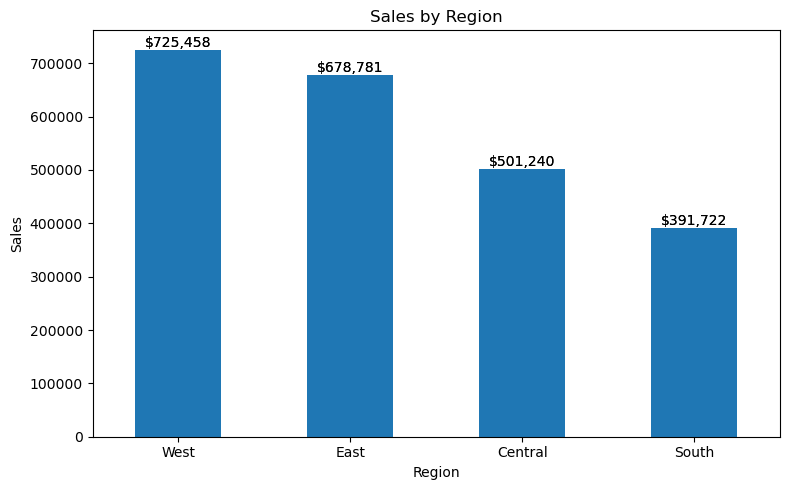

In [28]:
# Plot1
region_sales = (orders1.groupby("Region")["Sales"].sum().sort_values(ascending=False))
#ax = region_sales.plot( kind="bar", figsize=(8,5))
#plt.figure(figsize=(8, 5))
ax = region_sales.plot( kind="bar", figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
# Add value labels
for p in ax.patches:
    ax.annotate( f'${p.get_height():,.0f}', (p.get_x() + p.get_width()/2, p.get_height()),ha='center', va='bottom'  )
plt.tight_layout()
plt.show();

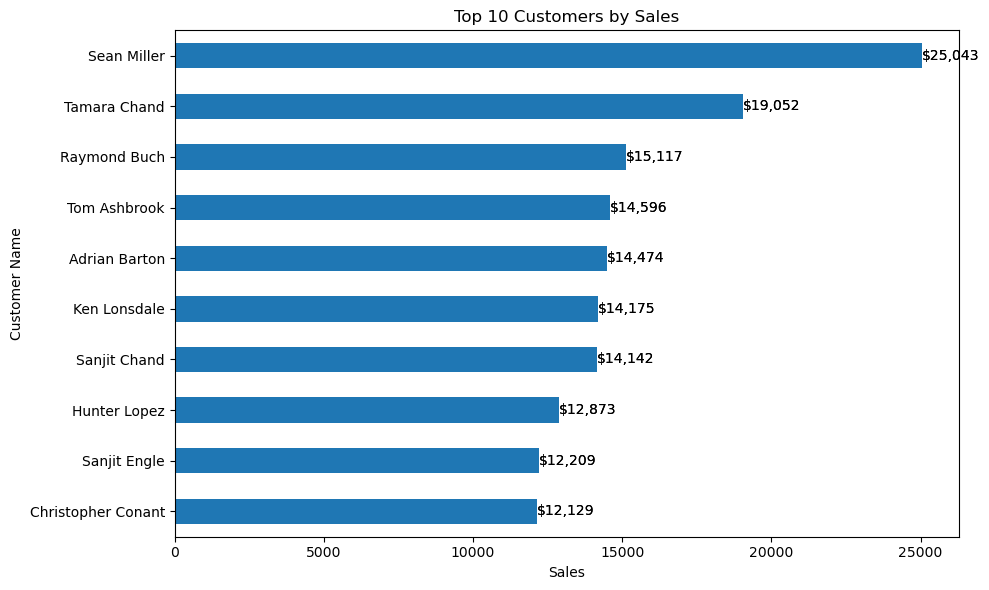

In [29]:
# Plot 2
top_customers = (orders1.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10).sort_values())
#plt.figure(figsize=(10, 6))
ax = top_customers.plot( kind="barh",  figsize=(10,6))
top_customers.sort_values().plot(kind="barh")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Name")
# Add value labels
for p in ax.patches:
    ax.annotate( f'${p.get_width():,.0f}', (p.get_width(), p.get_y() + p.get_height()/2), ha='left', va='center' )
plt.tight_layout()
plt.show();

In [18]:
orders1[["Customer Name", "Customer Total Sales"]].drop_duplicates().sort_values("Customer Total Sales", ascending=False).head(10)

,Customer Name,Customer Total Sales
2266,Sean Miller,25043.050
2072,Tamara Chand,19052.218
447,Raymond Buch,15117.339
2623,Tom Ashbrook,14595.620
1409,Adrian Barton,14473.571
237,Ken Lonsdale,14175.229
456,Sanjit Chand,14142.334
896,Hunter Lopez,12873.298
921,Sanjit Engle,12209.438
2857,Christopher Conant,12129.072


In [20]:
orders1.head()

,Region,State,Customer Name,Sales,Customer Total Sales,Customer Region Sales
0,South,Kentucky,Claire Gute,261.9600,1148.7800,993.9000
1,South,Kentucky,Claire Gute,731.9400,1148.7800,993.9000
2,West,California,Darrin Van Huff,14.6200,1119.4830,37.6000
3,South,Florida,Sean O'Donnell,957.5775,2602.5755,1438.9295
4,South,Florida,Sean O'Donnell,22.3680,2602.5755,1438.9295


In [23]:
orders1[orders1.duplicated()]

,Region,State,Customer Name,Sales,Customer Total Sales,Customer Region Sales
3279,South,Virginia,Greg Maxwell,22.960,6049.9660,4251.920
3406,East,Ohio,Laurel Beltran,281.372,4985.6760,1465.068
7608,West,California,Mike Kennedy,25.920,1031.6020,149.130
9684,West,California,Emily Phan,12.960,5478.0608,695.640


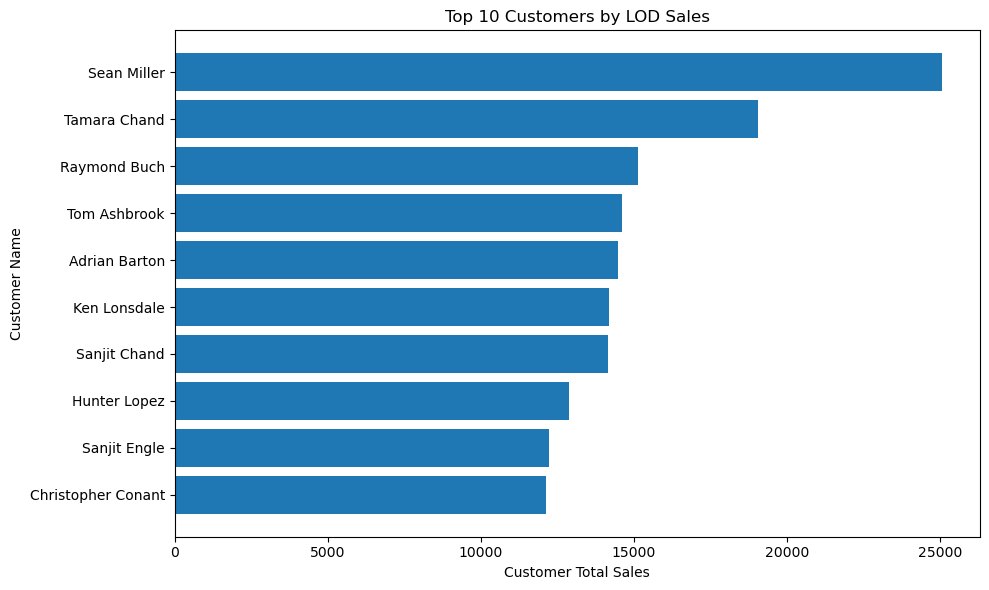

In [19]:
# Plot 3 - Tableau way of plotting
customer_lod_plot = ( orders1[["Customer Name", "Customer Total Sales"]].drop_duplicates().sort_values("Customer Total Sales", ascending=False).head(10))
plt.figure(figsize=(10, 6))
plt.barh(customer_lod_plot["Customer Name"][::-1],  customer_lod_plot["Customer Total Sales"][::-1])
plt.title("Top 10 Customers by LOD Sales")
plt.xlabel("Customer Total Sales")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show();

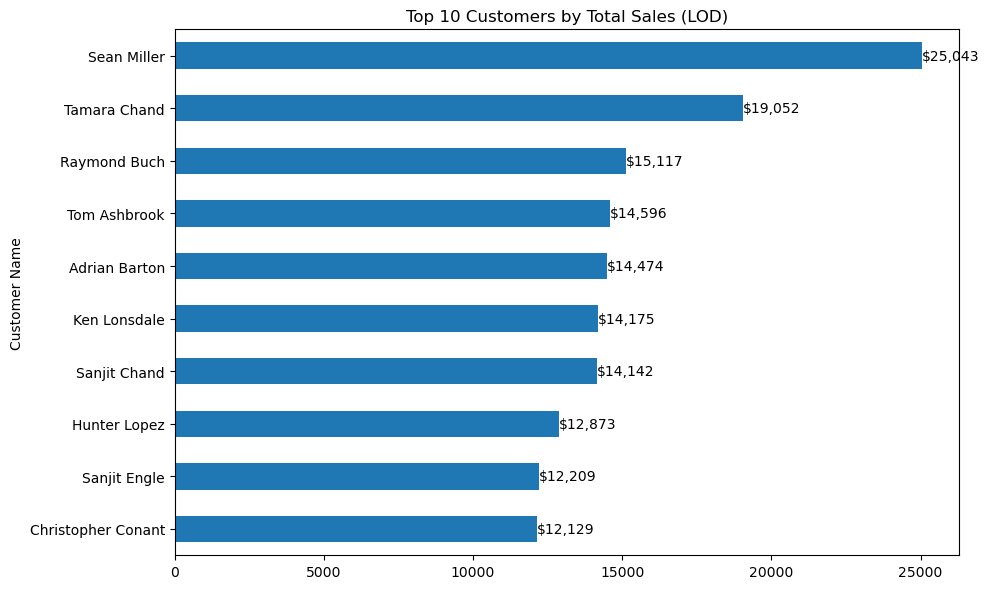

In [30]:
customer_lod = ( orders1[["Customer Name","Customer Total Sales"]].drop_duplicates().sort_values("Customer Total Sales", ascending=False).head(10).sort_values("Customer Total Sales"))
ax = customer_lod.plot( x="Customer Name",  y="Customer Total Sales", kind="barh", figsize=(10,6), legend=False)
plt.title("Top 10 Customers by Total Sales (LOD)")
# Labels
for p in ax.patches:
    ax.annotate(
        f'${p.get_width():,.0f}', (p.get_width(), p.get_y() + p.get_height()/2),   ha='left', va='center'  )
plt.tight_layout()
plt.show()

## commands : Table-> Python
- show Mark Labels -ax.annotate()
- FIXED LOD - groupby().transform()
- Sort Descending - sort_values(ascending=False)
- Top N Filter - .head(N)
- Horizontal Bars - kind='barh'